# Linear Regression

## 1. Dataset

In [40]:
X = [1, 2, 3, 4]
Y = [5, 7, 9, 11]

In [41]:
import random

w = random.random()
b = random.random()

## 2. Function

In [42]:
# Predict function for all x
def predict(X, weight, bias):
  Y_pred = []
  for x in X:
    Y_pred.append(weight * x + bias)
  return Y_pred

In [43]:
# Loss function for all points
def lossMSE(Y_pred, Y_true):
  n = len(Y_pred)
  result = 0
  for i in range(n):
    result += pow((Y_pred[i] - Y_true[i]), 2)
  return result / n

### Quá trình Đạo hàm Hàm hợp (Chain Rule) trong Linear Regression

Phương trình dự đoán: $\hat{y}_i = w x_i + b$
Hàm mất mát MSE với $n$ mẫu dữ liệu:
$$MSE = \frac{1}{n} \sum_{i=1}^{n} (\hat{y}_i - y_i)^2$$

Để tìm gradient theo $w$ và $b$, ta áp dụng quy tắc đạo hàm hàm hợp (Chain Rule):
$$\frac{\partial MSE}{\partial w} = \frac{\partial MSE}{\partial \hat{y}_i} \cdot \frac{\partial \hat{y}_i}{\partial w}$$
$$\frac{\partial MSE}{\partial b} = \frac{\partial MSE}{\partial \hat{y}_i} \cdot \frac{\partial \hat{y}_i}{\partial b}$$

---

### Bước 1: Đạo hàm hàm ngoài theo giá trị dự đoán $\frac{\partial MSE}{\partial \hat{y}_i}$
Lấy đạo hàm của hàm số MSE theo biến số $\hat{y}_i$ (coi $y_i$ là hằng số):
$$\frac{\partial MSE}{\partial \hat{y}_i} = \frac{2}{n} \sum_{i=1}^{n} (\hat{y}_i - y_i)$$

> **Ý nghĩa:** Đây là lượng sai số cơ bản giữa giá trị mô hình đoán và giá trị thực tế, là thành phần cốt lõi xuất hiện trong cả 2 công thức gradient.

---

### Bước 2: Đạo hàm hàm trong và kết quả cuối cùng

#### 1. Đạo hàm riêng theo trọng số $w$
Ta tìm tốc độ thay đổi của $\hat{y}_i$ theo $w$ bằng cách đạo hàm phương trình $\hat{y}_i = wx_i + b$ theo biến $w$ (coi $b$ là hằng số):
$$\frac{\partial \hat{y}_i}{\partial w} = x_i$$

Nhân kết quả của Bước 1 và Bước 2 lại với nhau, ta được công thức Gradient tổng chỉnh $w$:
$$\frac{\partial MSE}{\partial w} = \frac{\partial MSE}{\partial \hat{y}_i} \cdot \frac{\partial \hat{y}_i}{\partial w} = \frac{2}{n} \sum_{i=1}^{n} (\hat{y}_i - y_i) \cdot x_i$$

---

#### 2. Đạo hàm riêng theo hệ số tự do $b$
Ta tìm tốc độ thay đổi của $\hat{y}_i$ theo $b$ bằng cách đạo hàm phương trình $\hat{y}_i = wx_i + b$ theo biến $b$ (coi $w$ là hằng số):
$$\frac{\partial \hat{y}_i}{\partial b} = 1$$

Nhân kết quả của Bước 1 và Bước 2 lại với nhau, ta được công thức Gradient tổng chỉnh $b$:
$$\frac{\partial MSE}{\partial b} = \frac{\partial MSE}{\partial \hat{y}_i} \cdot \frac{\partial \hat{y}_i}{\partial b} = \frac{2}{n} \sum_{i=1}^{n} (\hat{y}_i - y_i) \cdot 1 = \frac{2}{n} \sum_{i=1}^{n} (\hat{y}_i - y_i)$$


In [44]:
# Gradient function
def gradient(X, Y_pred, Y_true):
  n = len(X)

  dMSE_dw = 0
  dMSE_db = 0

  for i in range(n):
    delta = (Y_pred[i] - Y_true[i])
    dMSE_db += delta
    dMSE_dw += delta * X[i]

  return ((2/n) * dMSE_dw), ((2/n) * dMSE_db)

## 3. Training

In [45]:
learning_rate = 0.01
epochs = 100

loss_history = []

for epoch in range(epochs):
  Y_pred = predict(X, w, b)

  loss = lossMSE(Y_pred, Y)
  loss_history.append(loss)

  dw, db = gradient(X, Y_pred, Y)

  w -= dw * learning_rate
  b -= db * learning_rate

  if epoch % 1 == 0:
    print(f"Epoch {epoch}, loss {loss}")

print("w =", w)
print("b =", b)

Epoch 0, loss 46.69171852645415
Epoch 1, loss 32.4906972517779
Epoch 2, loss 22.63635719909506
Epoch 3, loss 15.798090578209479
Epoch 4, loss 11.052616776938628
Epoch 5, loss 7.759290893763652
Epoch 6, loss 5.473582966871595
Epoch 7, loss 3.887043041804235
Epoch 8, loss 2.7856442021252814
Epoch 9, loss 2.020877679782866
Epoch 10, loss 1.4896963637625786
Epoch 11, loss 1.1205980250988017
Epoch 12, loss 0.8639687611622131
Epoch 13, loss 0.6853825159647966
Epoch 14, loss 0.5609517590683766
Epoch 15, loss 0.47410142004948436
Epoch 16, loss 0.4133303898813537
Epoch 17, loss 0.370658274104651
Epoch 18, loss 0.3405476277157769
Epoch 19, loss 0.3191561167586899
Epoch 20, loss 0.30381760907568356
Epoch 21, loss 0.2926821141578457
Epoch 22, loss 0.2844659450248547
Epoch 23, loss 0.2782783608388325
Epoch 24, loss 0.27350127788138595
Epoch 25, loss 0.26970580354503304
Epoch 26, loss 0.26659432103521397
Epoch 27, loss 0.2639603031697708
Epoch 28, loss 0.2616604280240576
Epoch 29, loss 0.25959523056

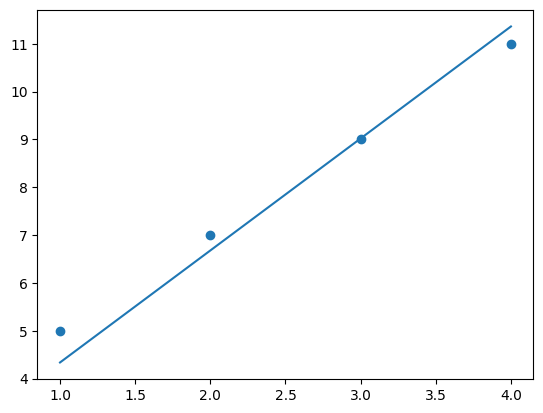

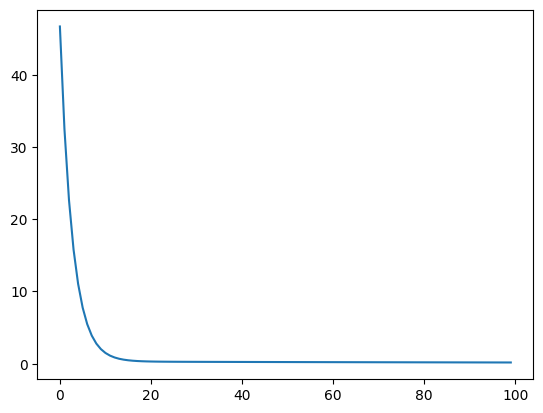

In [46]:
import matplotlib.pyplot as plt
plt.scatter(X, Y)
x_line = sorted(X)
y_line = predict(x_line, w, b)
plt.plot(x_line, y_line)
plt.show()

plt.plot(loss_history)
plt.show()

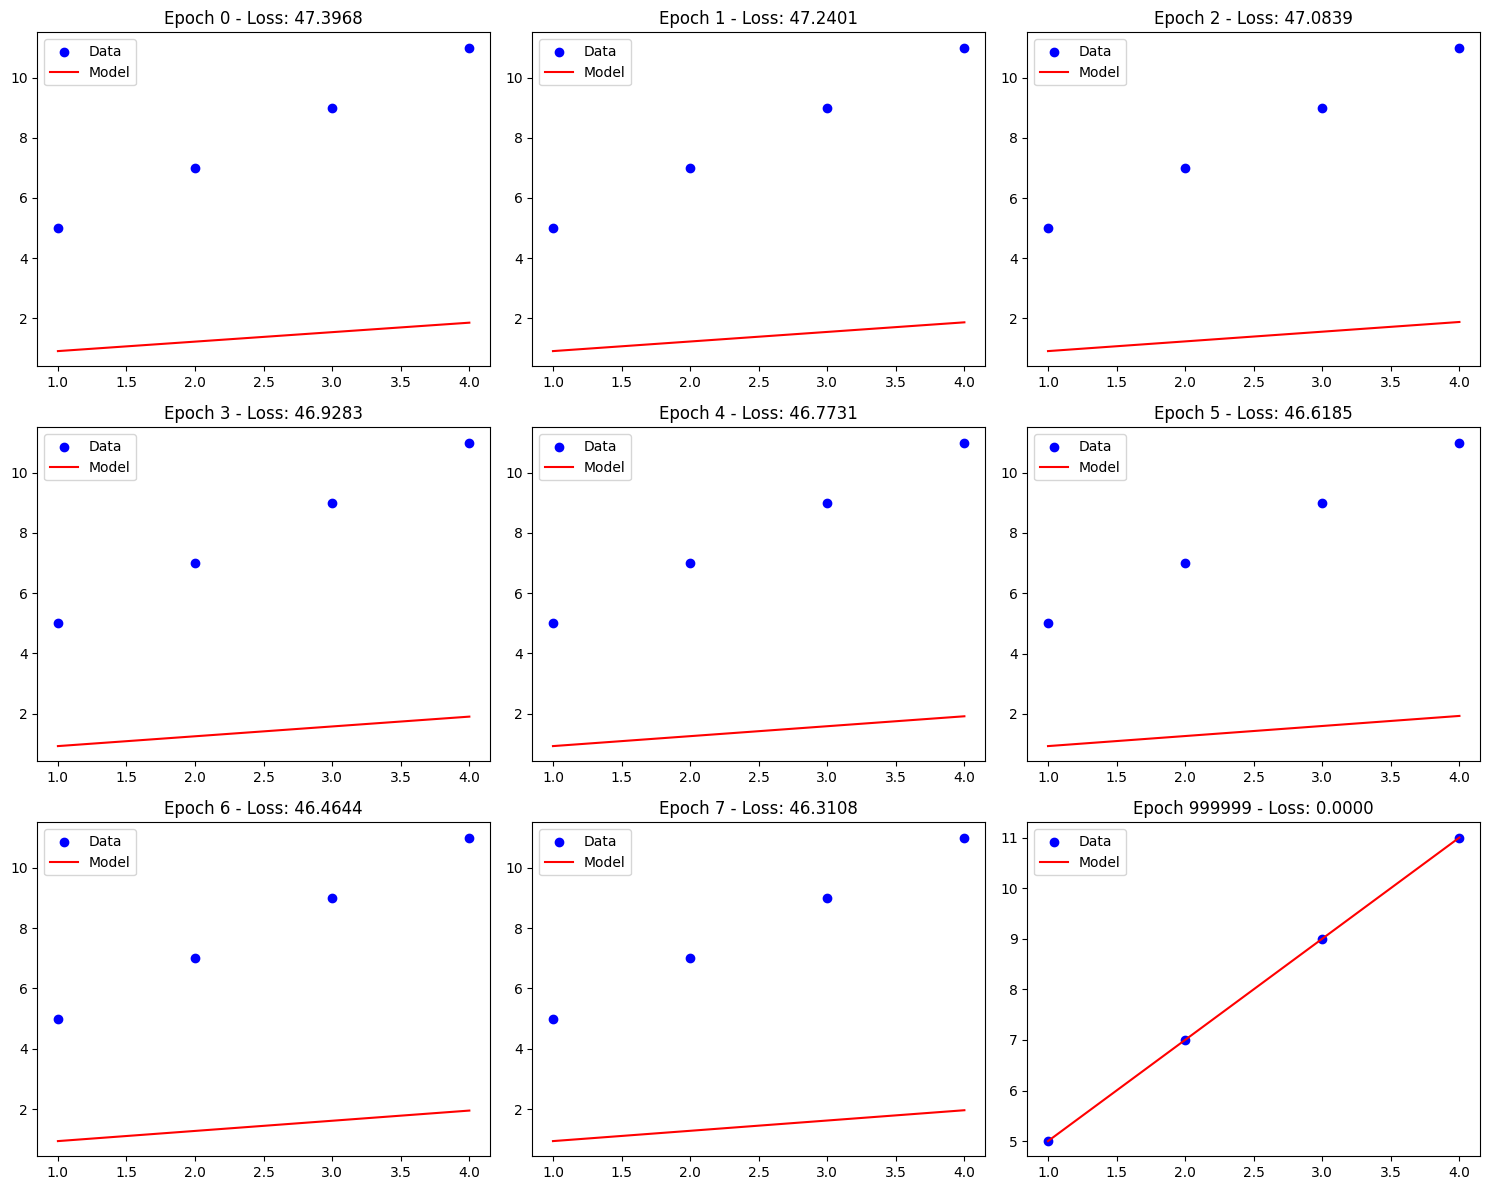

Final parameters: w = 2.0000, b = 3.0000


In [52]:
import random
X = [1, 2, 3, 4]
Y = [5, 7, 9, 11]
w = random.random()
b = random.random()

learning_rate = 0.0001
epochs = 1000000

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()
plot_idx = 0

for epoch in range(epochs):
    Y_pred = predict(X, w, b)
    loss = lossMSE(Y_pred, Y)
    loss_history.append(loss)

    # first 8 epochs and last epoch
    if epoch < 8 or epoch == epochs - 1:
        ax = axes[plot_idx]
        ax.scatter(X, Y, color='blue', label='Data')
        ax.plot(X, Y_pred, color='red', label='Model')
        ax.set_title(f"Epoch {epoch} - Loss: {loss:.4f}")
        ax.legend()
        plot_idx += 1

    dw, db = gradient(X, Y_pred, Y)
    w -= dw * learning_rate
    b -= db * learning_rate

plt.tight_layout()
plt.show()

print(f"Final parameters: w = {w:.4f}, b = {b:.4f}")